In [1]:
import sys; from pathlib import Path;
src_dir = next(parent / 'src' for parent in Path().absolute().parents if (parent / 'src').is_dir())
sys.path.extend([str(src_dir), str(src_dir / 'pipelines')])
main_dir = Path(src_dir.parents[0])
from imports import * ; current_dir = Path().resolve()  ; parent_dir = current_dir.parents[1]
one_drive_dir = mi.Utilities.get_one_drive_dir()

In [ ]:
data_dir =one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 Thermostability/thermal_stability_data_python.xlsx')
thermal_stability_data = pd.read_excel(data_dir, sheet_name=None)
results_dir = one_drive_dir.joinpath('General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Fig. 5 Thermostability')

In [5]:
# convert the data to a pandas DataFrame
thermal_stability_data = {sheet_name: pd.read_excel(data_dir, sheet_name='Sheet1') for sheet_name in thermal_stability_data.keys()}
# selecting the data from 4 to 70 C
thermal_stability_data = {sheet: df.iloc[0:12] for sheet, df in thermal_stability_data.items()}
thermal_stability_data
df = thermal_stability_data['Sheet1']
# add the degree Celsius to the ' Sample' temperature column values, removing the 'C' character with '°C'
df['Sample'] = df['Sample'].str.replace('C', '°C')
# df

In [ ]:
df

,Sample,Ratio of Ti/T0,SEM
0,4°C,1.000000,0.000000
1,50°C,0.000000,0.000000
2,60°C,0.000000,0.000000
3,70°C,0.000000,0.000000
4,4°C,1.000000,0.000000
5,50°C,1.343585,0.053316
6,60°C,0.746288,0.129874
7,70°C,0.000000,0.000000
8,4°C,1.000000,0.000000
9,50°C,0.786231,0.005232


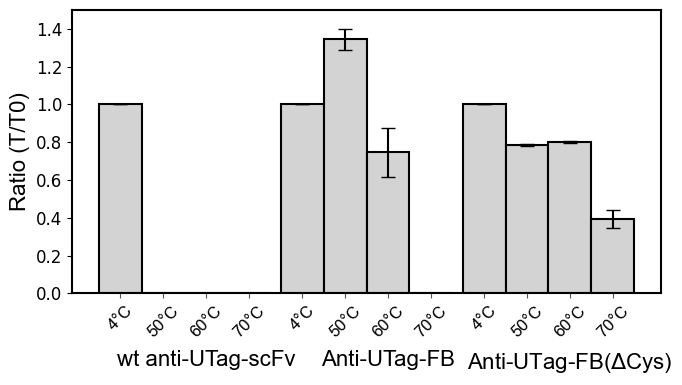

In [ ]:
df.columns = df.columns.str.strip()
bar_width = 0.85
group_gap = 0.2
group_sizes = [4, 4, 4]                
group_names = [
    "wt anti-UTag-scFv",
    "Anti-UTag-FB",
    "Anti-UTag-FB($\Delta$Cys)"
]

# --- compute x-positions ---
x_positions = []
group_starts = []
offset = 0.0
for size in group_sizes:
    group_starts.append(offset)
    # one group: size bars spaced by bar_width
    for i in range(size):
        x_positions.append(offset + i * bar_width)
    # move offset past this group + gap
    offset += size * bar_width + group_gap
x_positions = np.array(x_positions)

# --- plotting ---
fig, ax = plt.subplots(figsize=(7, 4), facecolor='white')
ax.set_facecolor('white')

ax.bar(
    x_positions,
    df['Ratio of Ti/T0'],
    width=bar_width,
    yerr=df['SEM'],
    capsize=5,
    color='lightgrey',
    edgecolor='black',
    linewidth=1.5
)

# styling
ax.grid(False)
ax.set_ylabel('Ratio (T/T0)', fontname="Arial", fontsize=16, color='black')
ax.tick_params(axis='y', labelsize=12, colors='black')

ax.set_xticks(x_positions)
ax.set_xticklabels(
    df['Sample'].astype(str),
    rotation=45,
    fontname="Arial",
    fontsize=12,
    color='black'
)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.5)

# place group labels centered under each block
for start, size, label in zip(group_starts, group_sizes, group_names):
    center = start + (size * bar_width) / 2
    ax.text(
        center, -0.2, label,
        ha='center', va='top',
        transform=ax.get_xaxis_transform(),
        fontsize=16, fontname="Arial", color='black'
    )
# y limit
ax.set_ylim(0, 1.5)
plt.tight_layout()
# save figure
plt.savefig(results_dir.joinpath('Figure_5C.png'), dpi=300, transparent=True, bbox_inches='tight')
plt.savefig(results_dir.joinpath('Figure_5C.svg'), dpi=300, transparent=True, bbox_inches='tight')

plt.show()